# Step 4: How much does the melt depend on the melt settings?

The three-equation melt model needs transfer coefficients: how fast heat and salt cross the thin boundary layer between the ocean and the ice. Their values are not well known. Here I change them in the step 3 setup (open-ocean restoring zone, far field -0.9 °C) and see how much the melt rate changes:

- `open_g05`: heat transfer coefficient halved (0.5e-4 m/s), salt coefficient follows at the fixed ratio;
- `open_g20`: heat transfer coefficient doubled (2.0e-4 m/s);
- `open_frict`: coefficients that depend on the current speed next to the ice (Holland and Jenkins 1999), instead of constants.

The reference is `open_p10` from step 3 (constant 1.0e-4 m/s). I chose it because it reached a steady melt rate in step 3, while the colder cases were still drifting, and because the step 6 resolution test uses the same far field. Every case runs 10 years from the same cold start.

I load the libraries and shared functions, and set the cases and paths.

In [1]:
%matplotlib inline

import os
import sys

import numpy as np
import matplotlib.pyplot as plt
from MITgcmutils import rdmds

sys.path.append("../src")   # isomip_tools.py lives in the project's src/ folder
from isomip_tools import read_grid, output_iterations, read_field, melt_rate, area_mean, melt_series, NX, NY

RUNS = os.path.expanduser("~/mitgcm_runs/isomip")
GEOMETRY_DIR = "../experiments/open_geometry"
CASES = ["open_g05", "open_p10", "open_g20", "open_frict"]
LABELS = {"open_g05": "gamma_T halved (0.5e-4 m/s)", "open_p10": "gamma_T default (1.0e-4 m/s)",
          "open_g20": "gamma_T doubled (2.0e-4 m/s)", "open_frict": "velocity-dependent gamma"}
GAMMA_T = {"open_g05": 0.5e-4, "open_p10": 1.0e-4, "open_g20": 2.0e-4}   # constant heat transfer coefficients (m/s)
STEADY_LIMIT = 2.0               # percent per year, as in step 3
FIG_DIR = "../figures"
DATA_DIR = "../data"
colors = {"open_g05": "tab:green", "open_p10": "tab:blue", "open_g20": "tab:red", "open_frict": "tab:purple"}

These are the only lines that differ between the cases' `data.shelfice` files and the reference.

In [2]:
def settings(case):
    lines = []
    for line in open(f"../experiments/{case}/input/data.shelfice"):
        if not line.startswith("#") and ("TransCoeff" in line or "GammaFrict" in line or "DragQuadratic" in line):
            lines.append(line.strip())
    return lines

for case in CASES:
    print(case, settings(case))

open_g05 ['SHELFICEuseGammaFrict = .FALSE.,', 'SHELFICEheatTransCoeff = 0.5E-4,']
open_p10 ['SHELFICEuseGammaFrict = .FALSE.,']
open_g20 ['SHELFICEuseGammaFrict = .FALSE.,', 'SHELFICEheatTransCoeff = 2.0E-4,']
open_frict ['SHELFICEuseGammaFrict = .TRUE.,', 'SHELFICEDragQuadratic = 2.5E-3,']


Checks: each run ended normally, its log has no NaN, and every monthly output is finite.

In [3]:
grid = read_grid(os.path.join(RUNS, "open_p10"), GEOMETRY_DIR, ice_file="icetopo_open_north.bin")
iced = grid["iced"]
for case in CASES:
    run = os.path.join(RUNS, case)
    text = open(os.path.join(run, "output.txt")).read()
    its = output_iterations(run, "shelfice_monthly")
    bad = 0
    for it in its:
        if not np.all(np.isfinite(rdmds(os.path.join(run, "shelfice_monthly"), it))):
            bad += 1
    print(f"{case:10s} ended normally: {'Execution ended Normally' in text} | {len(its)} monthly means ({bad} non-finite) | "
          f"last iteration {its[-1]}")

open_g05   ended normally: True | 121 monthly means (0 non-finite) | last iteration 174240
open_p10   ended normally: True | 121 monthly means (0 non-finite) | last iteration 174240


open_g20   ended normally: True | 121 monthly means (0 non-finite) | last iteration 174240


open_frict ended normally: True | 121 monthly means (0 non-finite) | last iteration 174240


Area-mean melt under the ice for every 30-day mean, and the steadiness test from step 3 (change between the last two 12-month means).

open_g05  : last 12 months 0.1797 m/yr | change -2.01% per year -> NOT steady
open_p10  : last 12 months 0.2074 m/yr | change -1.98% per year -> steady


open_g20  : last 12 months 0.2336 m/yr | change -2.13% per year -> NOT steady
open_frict: last 12 months 0.0587 m/yr | change -2.95% per year -> NOT steady


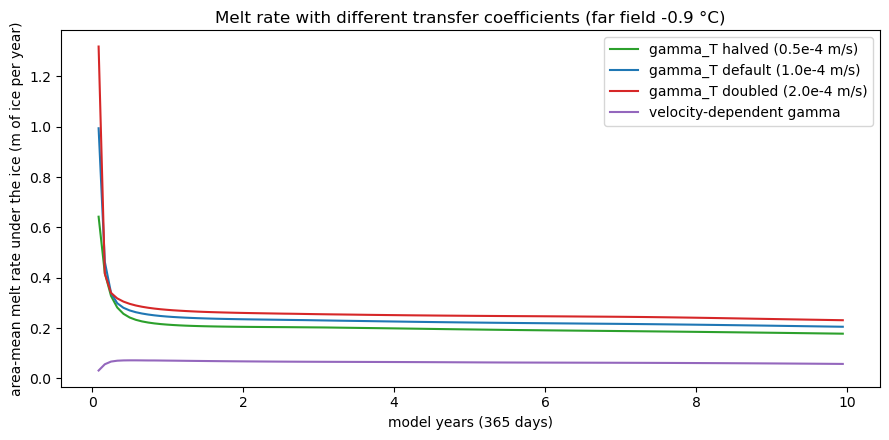

In [4]:
series = {}
steady = {}
change = {}
for case in CASES:
    days, melt = melt_series([os.path.join(RUNS, case)], grid, iced)
    series[case] = (days, melt)
    steady[case] = melt[-12:].mean()
    change[case] = 100 * (steady[case] - melt[-24:-12].mean()) / melt[-24:-12].mean()
    status = "steady" if abs(change[case]) < STEADY_LIMIT else "NOT steady"
    print(f"{case:10s}: last 12 months {steady[case]:.4f} m/yr | change {change[case]:+.2f}% per year -> {status}")

fig, ax = plt.subplots(figsize=(9, 4.5))
for case in CASES:
    days, melt = series[case]
    ax.plot(days / 365.0, melt, color=colors[case], label=LABELS[case])
ax.set_xlabel("model years (365 days)")
ax.set_ylabel("area-mean melt rate under the ice (m of ice per year)")
ax.set_title("Melt rate with different transfer coefficients (far field -0.9 °C)")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "04_melt_timeseries.png"), dpi=150)
plt.show()

How strongly does the melt follow the transfer coefficient? If melt = c x gamma^k, then k = 1 means the melt doubles when gamma doubles. I take k from each pair of cases (halved to default, default to doubled) and from a fit through all three.

In [5]:
g = np.array([GAMMA_T[c] for c in ["open_g05", "open_p10", "open_g20"]])
m = np.array([steady[c] for c in ["open_g05", "open_p10", "open_g20"]])
k_pairs = np.diff(np.log(m)) / np.diff(np.log(g))
k_fit = np.polyfit(np.log(g), np.log(m), 1)[0]
for c in ["open_g05", "open_g20", "open_frict"]:
    print(f"{c:10s}: melt / reference melt = {steady[c] / steady['open_p10']:.3f}")
print(f"exponent k: halved -> default {k_pairs[0]:.3f}, default -> doubled {k_pairs[1]:.3f}, fit through all three {k_fit:.3f}")

open_g05  : melt / reference melt = 0.866
open_g20  : melt / reference melt = 1.126
open_frict: melt / reference melt = 0.283
exponent k: halved -> default 0.207, default -> doubled 0.172, fit through all three 0.189


Why is k below 1 (if it is)? A bigger coefficient melts more at first, but the extra melt cools and freshens the water next to the ice, so the thermal driving there drops. I compare the thermal driving in the top wet cell under the ice for each case, using the last yearly mean of temperature and salinity.

In [6]:
from isomip_tools import freezing_point, pressure_dbar
driving = {}
for case in CASES:
    run = os.path.join(RUNS, case)
    last = output_iterations(run, "state_yearly")[-1]
    theta = read_field(run, "state_yearly", "THETA", last)
    salt = read_field(run, "state_yearly", "SALT", last)
    top = np.zeros((NY, NX))
    for j in range(NY):
        for i in range(NX):
            k = grid["ktop"][j, i]
            if iced[j, i] and k >= 0:
                top[j, i] = theta[k, j, i] - freezing_point(salt[k, j, i], pressure_dbar(-grid["rc"][k]))
    driving[case] = area_mean(top, grid, iced)
    print(f"{case:10s}: mean thermal driving in the top cell {driving[case]:.4f} °C")

open_g05  : mean thermal driving in the top cell 0.0049 °C
open_p10  : mean thermal driving in the top cell -0.0166 °C
open_g20  : mean thermal driving in the top cell -0.0301 °C
open_frict: mean thermal driving in the top cell 0.2885 °C


For `open_frict`, the model wrote the transfer coefficient it actually used (`SHIgammT`) and the friction velocity (`SHIuStar`). I average the last 12 months and compare them with the constant default of 1.0e-4 m/s.

SHIgammT under the ice: mean 9.938e-07 m/s, range 5.88e-07 to 4.93e-06
SHIuStar under the ice: mean 6.879e-05 m/s, range 3.87e-05 to 3.81e-04
area where gamma is above the constant default 1.0e-4: 0.0%


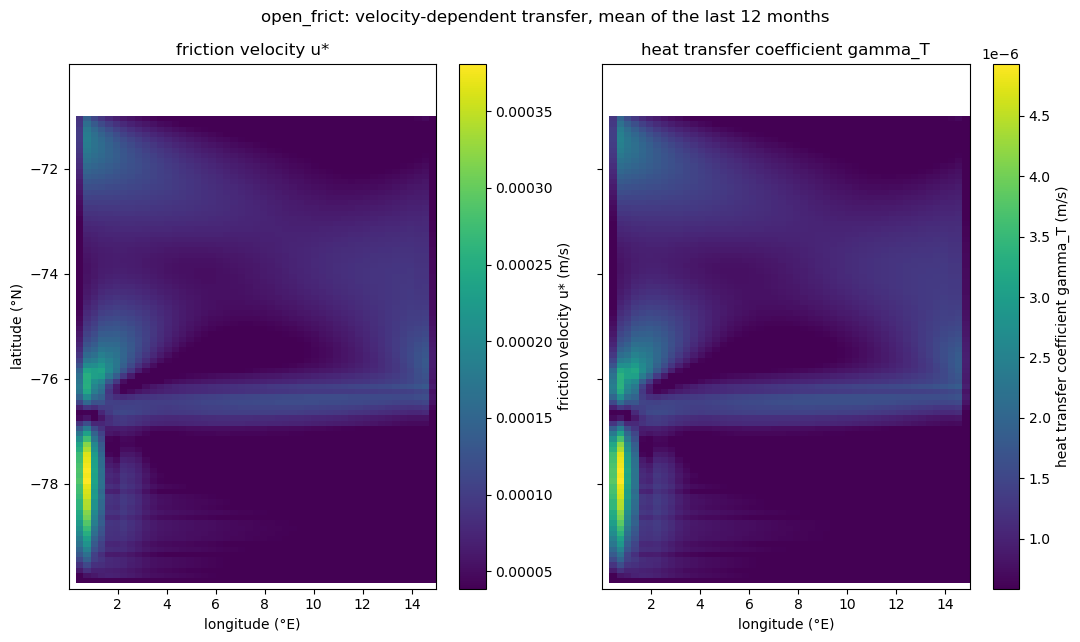

In [7]:
run = os.path.join(RUNS, "open_frict")
its = output_iterations(run, "shelfice_monthly")[-12:]
gam = np.zeros((NY, NX))
ustar = np.zeros((NY, NX))
for it in its:
    gam += read_field(run, "shelfice_monthly", "SHIgammT", it) / len(its)
    ustar += read_field(run, "shelfice_monthly", "SHIuStar", it) / len(its)
print(f"SHIgammT under the ice: mean {area_mean(gam, grid, iced):.3e} m/s, range {gam[iced].min():.2e} to {gam[iced].max():.2e}")
print(f"SHIuStar under the ice: mean {area_mean(ustar, grid, iced):.3e} m/s, range {ustar[iced].min():.2e} to {ustar[iced].max():.2e}")
print(f"area where gamma is above the constant default 1.0e-4: "
      f"{100 * np.sum(grid['rac'] * iced * (gam > 1e-4)) / np.sum(grid['rac'] * iced):.1f}%")

lat = grid["yc"][:, 0]
lon = grid["xc"][0, :]
lon_edges = np.concatenate([lon - 0.15, [lon[-1] + 0.15]])
lat_edges = np.concatenate([lat - 0.05, [lat[-1] + 0.05]])
fig, axes = plt.subplots(1, 2, figsize=(11, 6.5), sharey=True)
for ax, field, label in [(axes[0], ustar, "friction velocity u* (m/s)"), (axes[1], gam, "heat transfer coefficient gamma_T (m/s)")]:
    mesh = ax.pcolormesh(lon_edges, lat_edges, np.where(iced, field, np.nan), cmap="viridis")
    fig.colorbar(mesh, ax=ax, label=label)
    ax.set_xlabel("longitude (°E)")
    ax.set_title(label.split(" (")[0])
axes[0].set_ylabel("latitude (°N)")
fig.suptitle("open_frict: velocity-dependent transfer, mean of the last 12 months")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "04_frict_gamma_ustar.png"), dpi=150)
plt.show()

In `shelfice_thermodynamics.F` the friction velocity is u* = sqrt(shiCdrag x max(1e-6, u^2 + v^2)). So the current next to the ice is never counted as slower than 1 mm/s, and shiCdrag keeps its default of 1.5e-3 (my `SHELFICEDragQuadratic = 2.5E-3` only sets the drag on the flow). The smallest possible u* is therefore sqrt(1.5e-3 x 1e-6) = 3.87e-5 m/s. How much of the ice sits at that floor?

In [8]:
SHI_CDRAG = 1.5e-3                     # shiCdrag default, used for u*
ustar_floor = np.sqrt(SHI_CDRAG * 1e-6)
monthly = []
for it in its:
    monthly.append(read_field(run, "shelfice_monthly", "SHIuStar", it))
monthly = np.array(monthly)
always_floor = iced & np.all(monthly < 1.001 * ustar_floor, axis=0)
print(f"u* floor {ustar_floor:.3e} m/s | ice area at the floor in all of the last 12 months: "
      f"{100 * np.sum(grid['rac'] * always_floor) / np.sum(grid['rac'] * iced):.1f}%")

u* floor 3.873e-05 m/s | ice area at the floor in all of the last 12 months: 25.6%


Melt maps of the four cases (mean of the last 12 months) on one colour scale, so the patterns can be compared directly.

open_g05  : largest melt 3.707 m/yr, strongest refreezing -0.274 m/yr
open_p10  : largest melt 6.110 m/yr, strongest refreezing -0.459 m/yr
open_g20  : largest melt 9.580 m/yr, strongest refreezing -0.685 m/yr
open_frict: largest melt 0.545 m/yr, strongest refreezing -0.005 m/yr


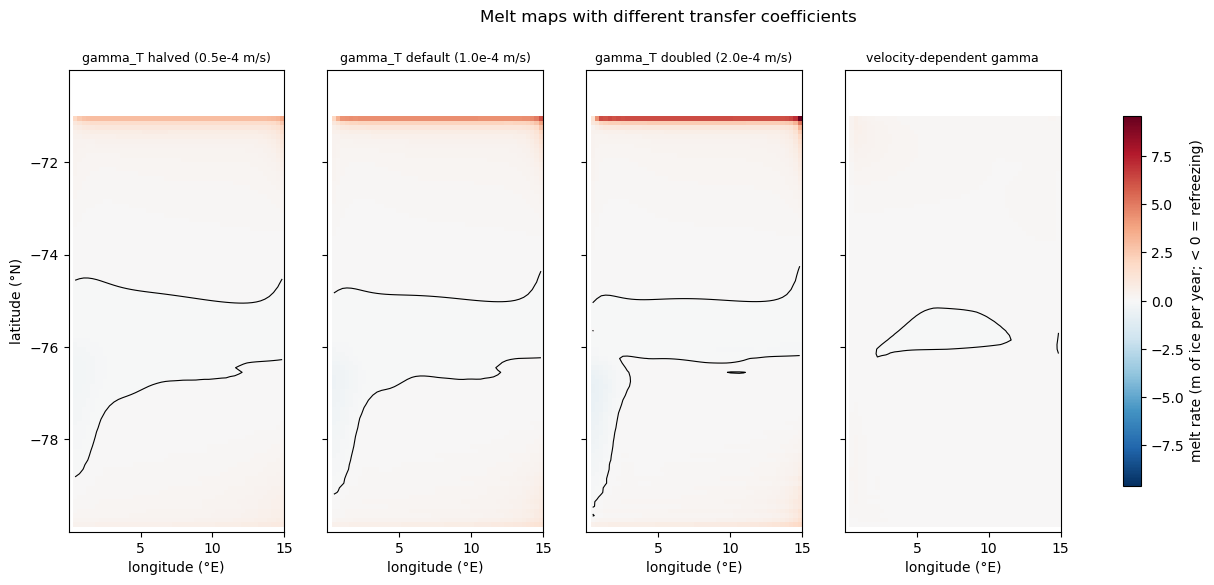

In [9]:
maps = {}
for case in CASES:
    run = os.path.join(RUNS, case)
    mm = np.zeros((NY, NX))
    its = output_iterations(run, "shelfice_monthly")[-12:]
    for it in its:
        mm += melt_rate(read_field(run, "shelfice_monthly", "SHIfwFlx", it)) / len(its)
    maps[case] = np.where(iced, mm, np.nan)
lim = max(np.nanmax(np.abs(maps[c])) for c in CASES)
fig, axes = plt.subplots(1, 4, figsize=(16, 6), sharey=True)
for ax, case in zip(axes, CASES):
    mesh = ax.pcolormesh(lon_edges, lat_edges, maps[case], cmap="RdBu_r", vmin=-lim, vmax=lim)
    ax.contour(lon, lat, maps[case], levels=[0], colors="k", linewidths=0.8)
    ax.set_title(LABELS[case], fontsize=9)
    ax.set_xlabel("longitude (°E)")
    print(f"{case:10s}: largest melt {np.nanmax(maps[case]):.3f} m/yr, strongest refreezing {np.nanmin(maps[case]):.3f} m/yr")
axes[0].set_ylabel("latitude (°N)")
fig.colorbar(mesh, ax=axes, label="melt rate (m of ice per year; < 0 = refreezing)", shrink=0.8)
fig.suptitle("Melt maps with different transfer coefficients")
fig.savefig(os.path.join(FIG_DIR, "04_melt_maps.png"), dpi=150, bbox_inches="tight")
plt.show()

Overturning strength in each case, as in step 3, and the results saved to a small table.

In [10]:
overturning = {}
for case in CASES:
    run = os.path.join(RUNS, case)
    last = output_iterations(run, "state_yearly")[-1]
    vvel = read_field(run, "state_yearly", "VVEL", last)
    v_transport = np.sum(vvel * grid["hfacs"] * grid["dxg"][None, :, :], axis=2) * grid["drf"][:, None]
    overturning[case] = np.abs(np.cumsum(v_transport, axis=0)).max() / 1e3
    print(f"{case:10s}: largest overturning {overturning[case]:6.1f} mSv")

with open(os.path.join(DATA_DIR, "melt_sensitivity.csv"), "w") as f:
    f.write("case,setting,steady_melt_m_per_yr,ratio_to_reference,change_last_year_percent,top_cell_thermal_driving_c,overturning_msv\n")
    for case in CASES:
        f.write(f"{case},{LABELS[case]},{steady[case]:.5f},{steady[case] / steady['open_p10']:.4f},{change[case]:.2f},"
                f"{driving[case]:.5f},{overturning[case]:.1f}\n")
print("saved", os.path.join(DATA_DIR, "melt_sensitivity.csv"))

open_g05  : largest overturning   75.4 mSv
open_p10  : largest overturning   77.1 mSv
open_g20  : largest overturning   77.1 mSv
open_frict: largest overturning   99.0 mSv
saved ../data/melt_sensitivity.csv
